In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [19]:
!pip install -q unsloth
print("✅ Cài xong!")

✅ Cài xong!


In [20]:
import os

for root, dirs, files in os.walk('/kaggle/input/llama3-en-vi-adapter'):
    for f in files:
        print(os.path.join(root, f))

In [21]:
import os

# Kiểm tra tất cả input có sẵn
print(os.listdir('/kaggle/input'))

['datasets']


In [22]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/README.md
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/adapter_model.safetensors
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/adapter_config.json
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/README.md
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/tokenizer.json
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/tokenizer_config.json
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final/chat_template.jinja
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/checkpoint-3125/adapter_model.safetensors
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/checkpoint-3125/trainer_state.json
/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter

In [23]:
from unsloth import FastLanguageModel

ADAPTER_DIR = '/kaggle/input/datasets/rtnhiuthanhthao/llama3-en-vi-adapter/llama3-en-vi/adapter-final'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_DIR,
    max_seq_length=256,
    load_in_4bit=True,
    dtype=None,
)

FastLanguageModel.for_inference(model)
print("✅ Model sẵn sàng inference!")

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth 2026.5.2 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ Model sẵn sàng inference!


In [24]:
import torch

SYSTEM_PROMPT = (
    'You are a professional English-Vietnamese translator. '
    'Translate the given English text to Vietnamese accurately and naturally.'
)

def translate(text, max_new_tokens=150):
    prompt = (
        '<|begin_of_text|>'
        '<|start_header_id|>system<|end_header_id|>\n'
        f'{SYSTEM_PROMPT}<|eot_id|>\n'
        '<|start_header_id|>user<|end_header_id|>\n'
        f'Translate to Vietnamese:\n{text}<|eot_id|>\n'
        '<|start_header_id|>assistant<|end_header_id|>\n'
    )
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

# Test thử
print(translate("Artificial intelligence is transforming the world."))

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

Kỹ thuật trí tuệ nhân tạo đang thay đổi thế giới.


In [28]:
!pip install -q sacrebleu datasets evaluate bert-score

In [29]:
from datasets import load_dataset

NUM_TEST = 500

def filter_length(example):
    if not example['en'] or not example['vi']:
        return False
    en_len = len(example['en'].split())
    vi_len = len(example['vi'].split())
    return 3 <= en_len <= 80 and 3 <= vi_len <= 100

print('📥 Đang load PhoMT...')
dataset = load_dataset('ura-hcmut/PhoMT')
print('✅ Load xong!')

📥 Đang load PhoMT...


Generating train split:   0%|          | 0/2977999 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18720 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19151 [00:00<?, ? examples/s]

✅ Load xong!


In [30]:
from sacrebleu.metrics import BLEU, TER, CHRF
from evaluate import load
from tqdm import tqdm
import torch

# ── Chạy inference trên test set ──────────────────────────────
test_samples = dataset['test'].filter(filter_length).select(range(NUM_TEST))
hypotheses, references_flat = [], []

print(f'🔍 Evaluating {NUM_TEST} câu...')
for sample in tqdm(test_samples):
    hypotheses.append(translate(sample['en']))
    references_flat.append(sample['vi'])

references_list = [[r] for r in references_flat]  # format cho sacrebleu

# ── BLEU ──────────────────────────────────────────────────────
bleu = BLEU()
bleu_score = bleu.corpus_score(hypotheses, references_list)
print(f'\n📊 BLEU   : {bleu_score.score:.2f}')
print('   > 25: Tốt | > 30: Rất tốt | > 35: Xuất sắc')

# ── chrF (Character n-gram F-score) ───────────────────────────
chrf = CHRF()
chrf_score = chrf.corpus_score(hypotheses, references_list)
print(f'📊 chrF   : {chrf_score.score:.2f}  (0–100, càng cao càng tốt)')

# ── TER (Translation Edit Rate) ───────────────────────────────
ter = TER()
ter_score = ter.corpus_score(hypotheses, references_list)
print(f'📊 TER    : {ter_score.score:.2f}  (càng thấp càng tốt, 0 = hoàn hảo)')

# ── METEOR ────────────────────────────────────────────────────
meteor = load('meteor')
meteor_score = meteor.compute(predictions=hypotheses, references=references_flat)
print(f'📊 METEOR : {meteor_score["meteor"]:.4f}  (0–1, càng cao càng tốt)')

# ── BERTScore ─────────────────────────────────────────────────
bertscore = load('bertscore')
bert_results = bertscore.compute(
    predictions=hypotheses,
    references=references_flat,
    lang='vi',          # tiếng Việt
    model_type='bert-base-multilingual-cased',
    batch_size=16,
)
p = sum(bert_results['precision']) / len(bert_results['precision'])
r = sum(bert_results['recall'])    / len(bert_results['recall'])
f = sum(bert_results['f1'])        / len(bert_results['f1'])
print(f'📊 BERTScore: P={p:.4f} | R={r:.4f} | F1={f:.4f}  (0–1, càng cao càng tốt)')

Filter:   0%|          | 0/19151 [00:00<?, ? examples/s]

🔍 Evaluating 500 câu...


  0%|          | 0/500 [00:00<?, ?it/s]Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, 


📊 BLEU   : 25.98
   > 25: Tốt | > 30: Rất tốt | > 35: Xuất sắc
📊 chrF   : 62.39  (0–100, càng cao càng tốt)
📊 TER    : 34.07  (càng thấp càng tốt, 0 = hoàn hảo)


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


📊 METEOR : 0.5869  (0–1, càng cao càng tốt)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 BERTScore: P=0.8717 | R=0.8666 | F1=0.8690  (0–1, càng cao càng tốt)


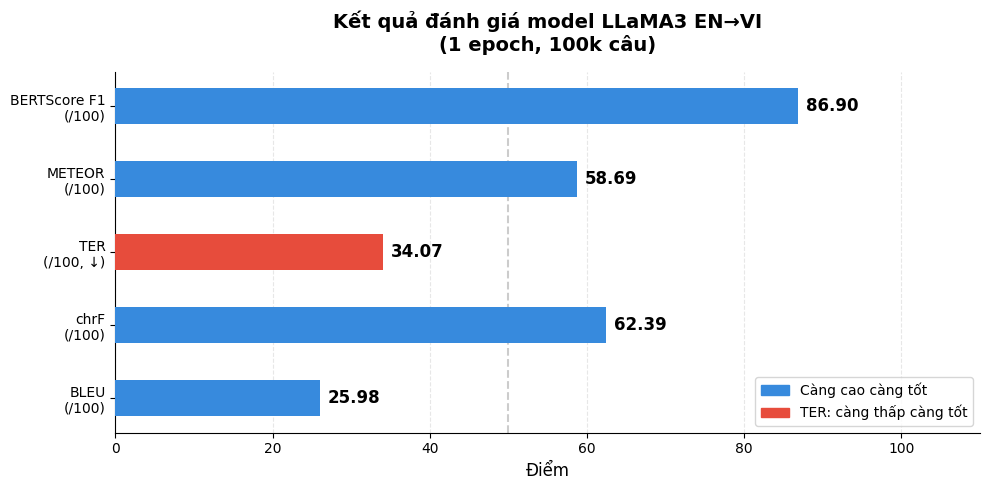

✅ Đã lưu metrics.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics = {
    'BLEU\n(/100)':        25.98,
    'chrF\n(/100)':        62.39,
    'TER\n(/100, ↓)':     34.07,
    'METEOR\n(/100)':      58.69,
    'BERTScore F1\n(/100)': 86.90,
}

labels = list(metrics.keys())
values = list(metrics.values())
colors = ['#e74c3c' if 'TER' in l else '#378ADD' for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels, values, color=colors, height=0.5, zorder=3)

for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='left', fontsize=12, fontweight='bold')

ax.set_xlim(0, 110)
ax.set_xlabel('Điểm', fontsize=12)
ax.set_title('Kết quả đánh giá model LLaMA3 EN→VI\n(1 epoch, 100k câu)', fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.4, zorder=2)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

blue_patch = mpatches.Patch(color='#378ADD', label='Càng cao càng tốt')
red_patch  = mpatches.Patch(color='#e74c3c', label='TER: càng thấp càng tốt')
ax.legend(handles=[blue_patch, red_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu metrics.png")

In [32]:
!pip install -q gradio

import gradio as gr
import torch

SYSTEM_PROMPT = (
    'You are a professional English-Vietnamese translator. '
    'Translate the given English text to Vietnamese accurately and naturally.'
)

def translate(text):
    if not text.strip():
        return "⚠️ Vui lòng nhập văn bản!"
    prompt = (
        '<|begin_of_text|>'
        '<|start_header_id|>system<|end_header_id|>\n'
        f'{SYSTEM_PROMPT}<|eot_id|>\n'
        '<|start_header_id|>user<|end_header_id|>\n'
        f'Translate to Vietnamese:\n{text}<|eot_id|>\n'
        '<|start_header_id|>assistant<|end_header_id|>\n'
    )
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

demo = gr.Interface(
    fn=translate,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Nhập văn bản tiếng Anh...",
        label="🇺🇸 English"
    ),
    outputs=gr.Textbox(
        lines=5,
        label="🇻🇳 Tiếng Việt"
    ),
    title="🦙 LLaMA En→Vi Translator",
    description="Fine-tuned LLaMA 3.2 trên PhoMT 100k samples",
    examples=[
        ["Artificial intelligence is transforming the world."],
        ["She walked slowly along the river bank, enjoying the sunset."],
        ["The meeting has been postponed to next Monday."],
        ["Vietnam is a beautiful country with a rich cultural heritage."],
    ],
    theme=gr.themes.Soft(),
)

# share=True tự tạo public URL, dùng được ~72 giờ
demo.launch(share=True, quiet=True)

* Running on public URL: https://e0a6bb18963997cb17.gradio.live


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

Created dataset file at: .gradio/flagged/dataset1.csv
